# 08. Generación de gráficas diarias

Este notebook genera las representaciones gráficas asociadas a cada documento diario de MongoDB.

Las imágenes se almacenarán como archivos PNG en el sistema de archivos del proyecto. MongoDB no almacenará directamente los archivos binarios, sino sus rutas y metadatos dentro del documento correspondiente a cada fecha.

En esta fase se utiliza únicamente un día de prueba para definir y validar las gráficas antes de automatizar su generación para todo el conjunto de datos.

In [55]:
from datetime import datetime, timezone
import pandas as pd

In [56]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Raíz del proyecto añadida: {project_root}")

Raíz del proyecto añadida: c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS


In [57]:
from src.mongodb.daily_summary import build_daily_document
from src.database.connection import get_database_engine
from src.database.load_daily_measurements import load_daily_measurements
from src.mongodb.daily_plots import generate_quality_weather_plot, generate_solar_curves_plot

engine = get_database_engine()

test_date = "2023-07-15"

df_day = load_daily_measurements(
    engine=engine,
    date=test_date,
)

daily_document = build_daily_document(
    df=df_day,
    dataset_version="v3",
)

print(f"Número de registros: {len(df_day):,}")
print(f"Fecha mínima: {df_day['fecha'].min()}")
print(f"Fecha máxima: {df_day['fecha'].max()}")
print(f"Número de columnas: {df_day.shape[1]}")
print(f"Fechas duplicadas: {df_day['fecha'].duplicated().sum()}")

Número de registros: 1,440
Fecha mínima: 2023-07-15 00:00:00
Fecha máxima: 2023-07-15 23:59:00
Número de columnas: 29
Fechas duplicadas: 0


In [58]:
df_day = df_day.copy()

df_day["fecha"] = pd.to_datetime(
    df_day["fecha"],
    errors="coerce",
)

if df_day["fecha"].isna().any():
    raise ValueError(
        "Existen fechas que no se han podido convertir correctamente."
    )

print(f"Fecha inicial para la gráfica: {df_day['fecha'].min()}")
print(f"Fecha final para la gráfica: {df_day['fecha'].max()}")

Fecha inicial para la gráfica: 2023-07-15 00:00:00
Fecha final para la gráfica: 2023-07-15 23:59:00


In [59]:
df_day["hora_local"] = df_day["fecha"]

In [60]:
document_date = df_day["fecha"].dt.date.iloc[0]
document_year = document_date.year

output_directory = (
    Path("../outputs/daily_plots")
    / str(document_year)
)

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Directorio de salida: {output_directory.resolve()}")

Directorio de salida: C:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\outputs\daily_plots\2023


In [61]:
solar_curves_path = generate_solar_curves_plot(
    df=df_day,
    output_directory=output_directory,
)

print(f"Gráfica generada: {solar_curves_path}")

Gráfica generada: ..\outputs\daily_plots\2023\2023-07-15_solar_curves.png


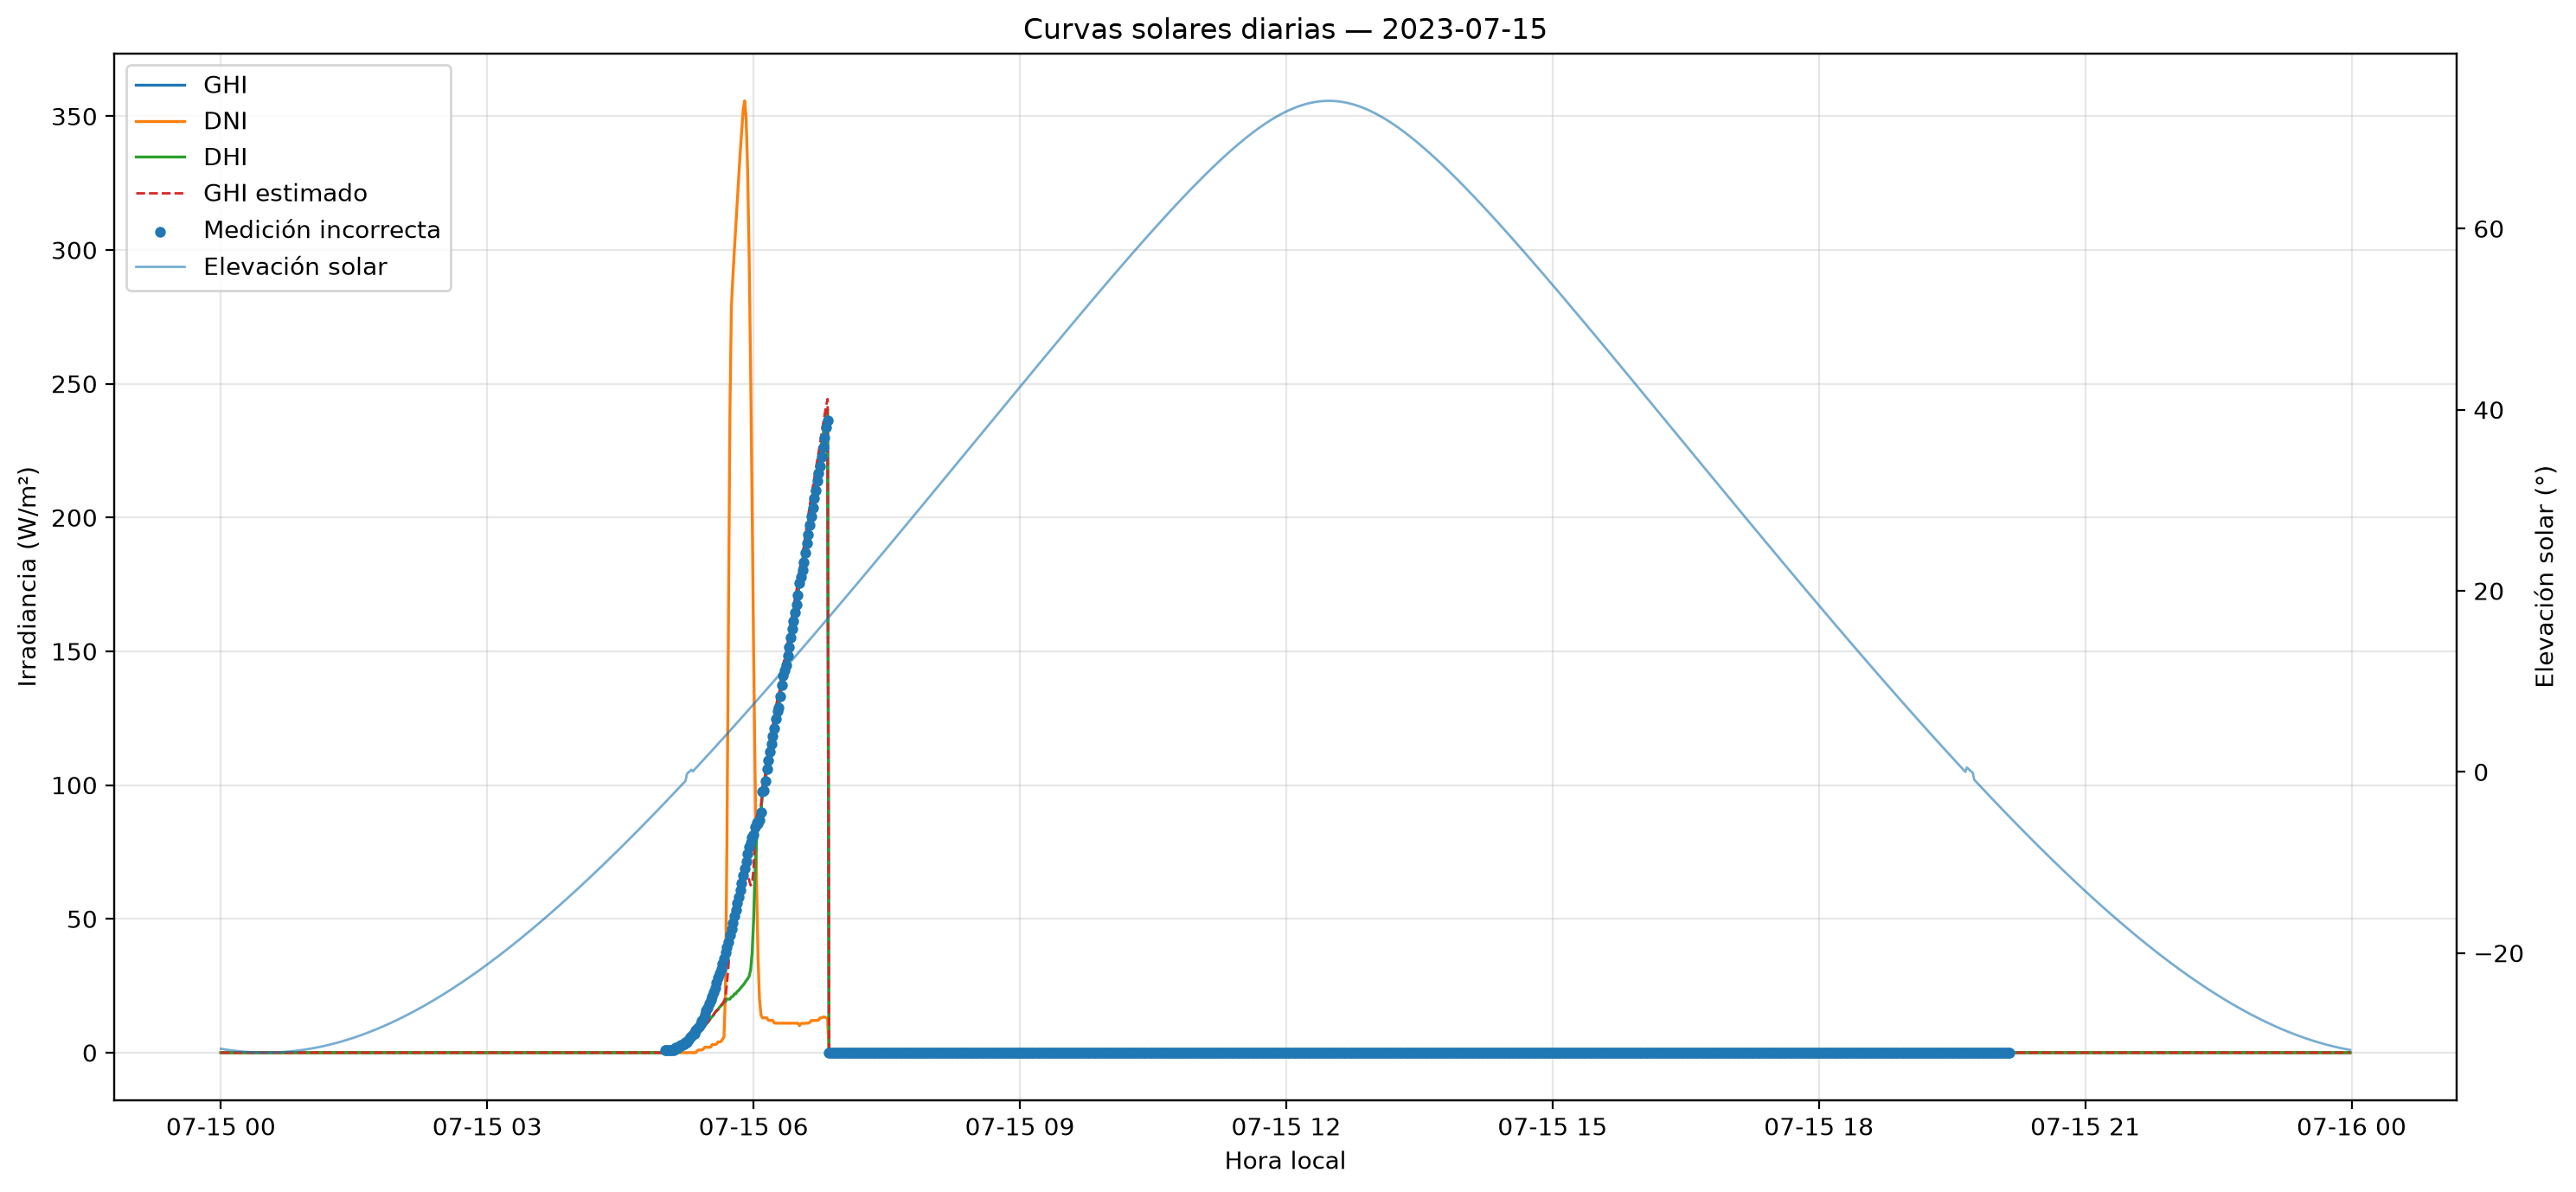

In [62]:
from IPython.display import Image, display

display(
    Image(
        filename=str(solar_curves_path)
    )
)

In [63]:
quality_weather_path = generate_quality_weather_plot(
    df=df_day,
    output_directory=output_directory,
)

print(f"Gráfica generada: {quality_weather_path}")

Gráfica generada: ..\outputs\daily_plots\2023\2023-07-15_quality_weather.png


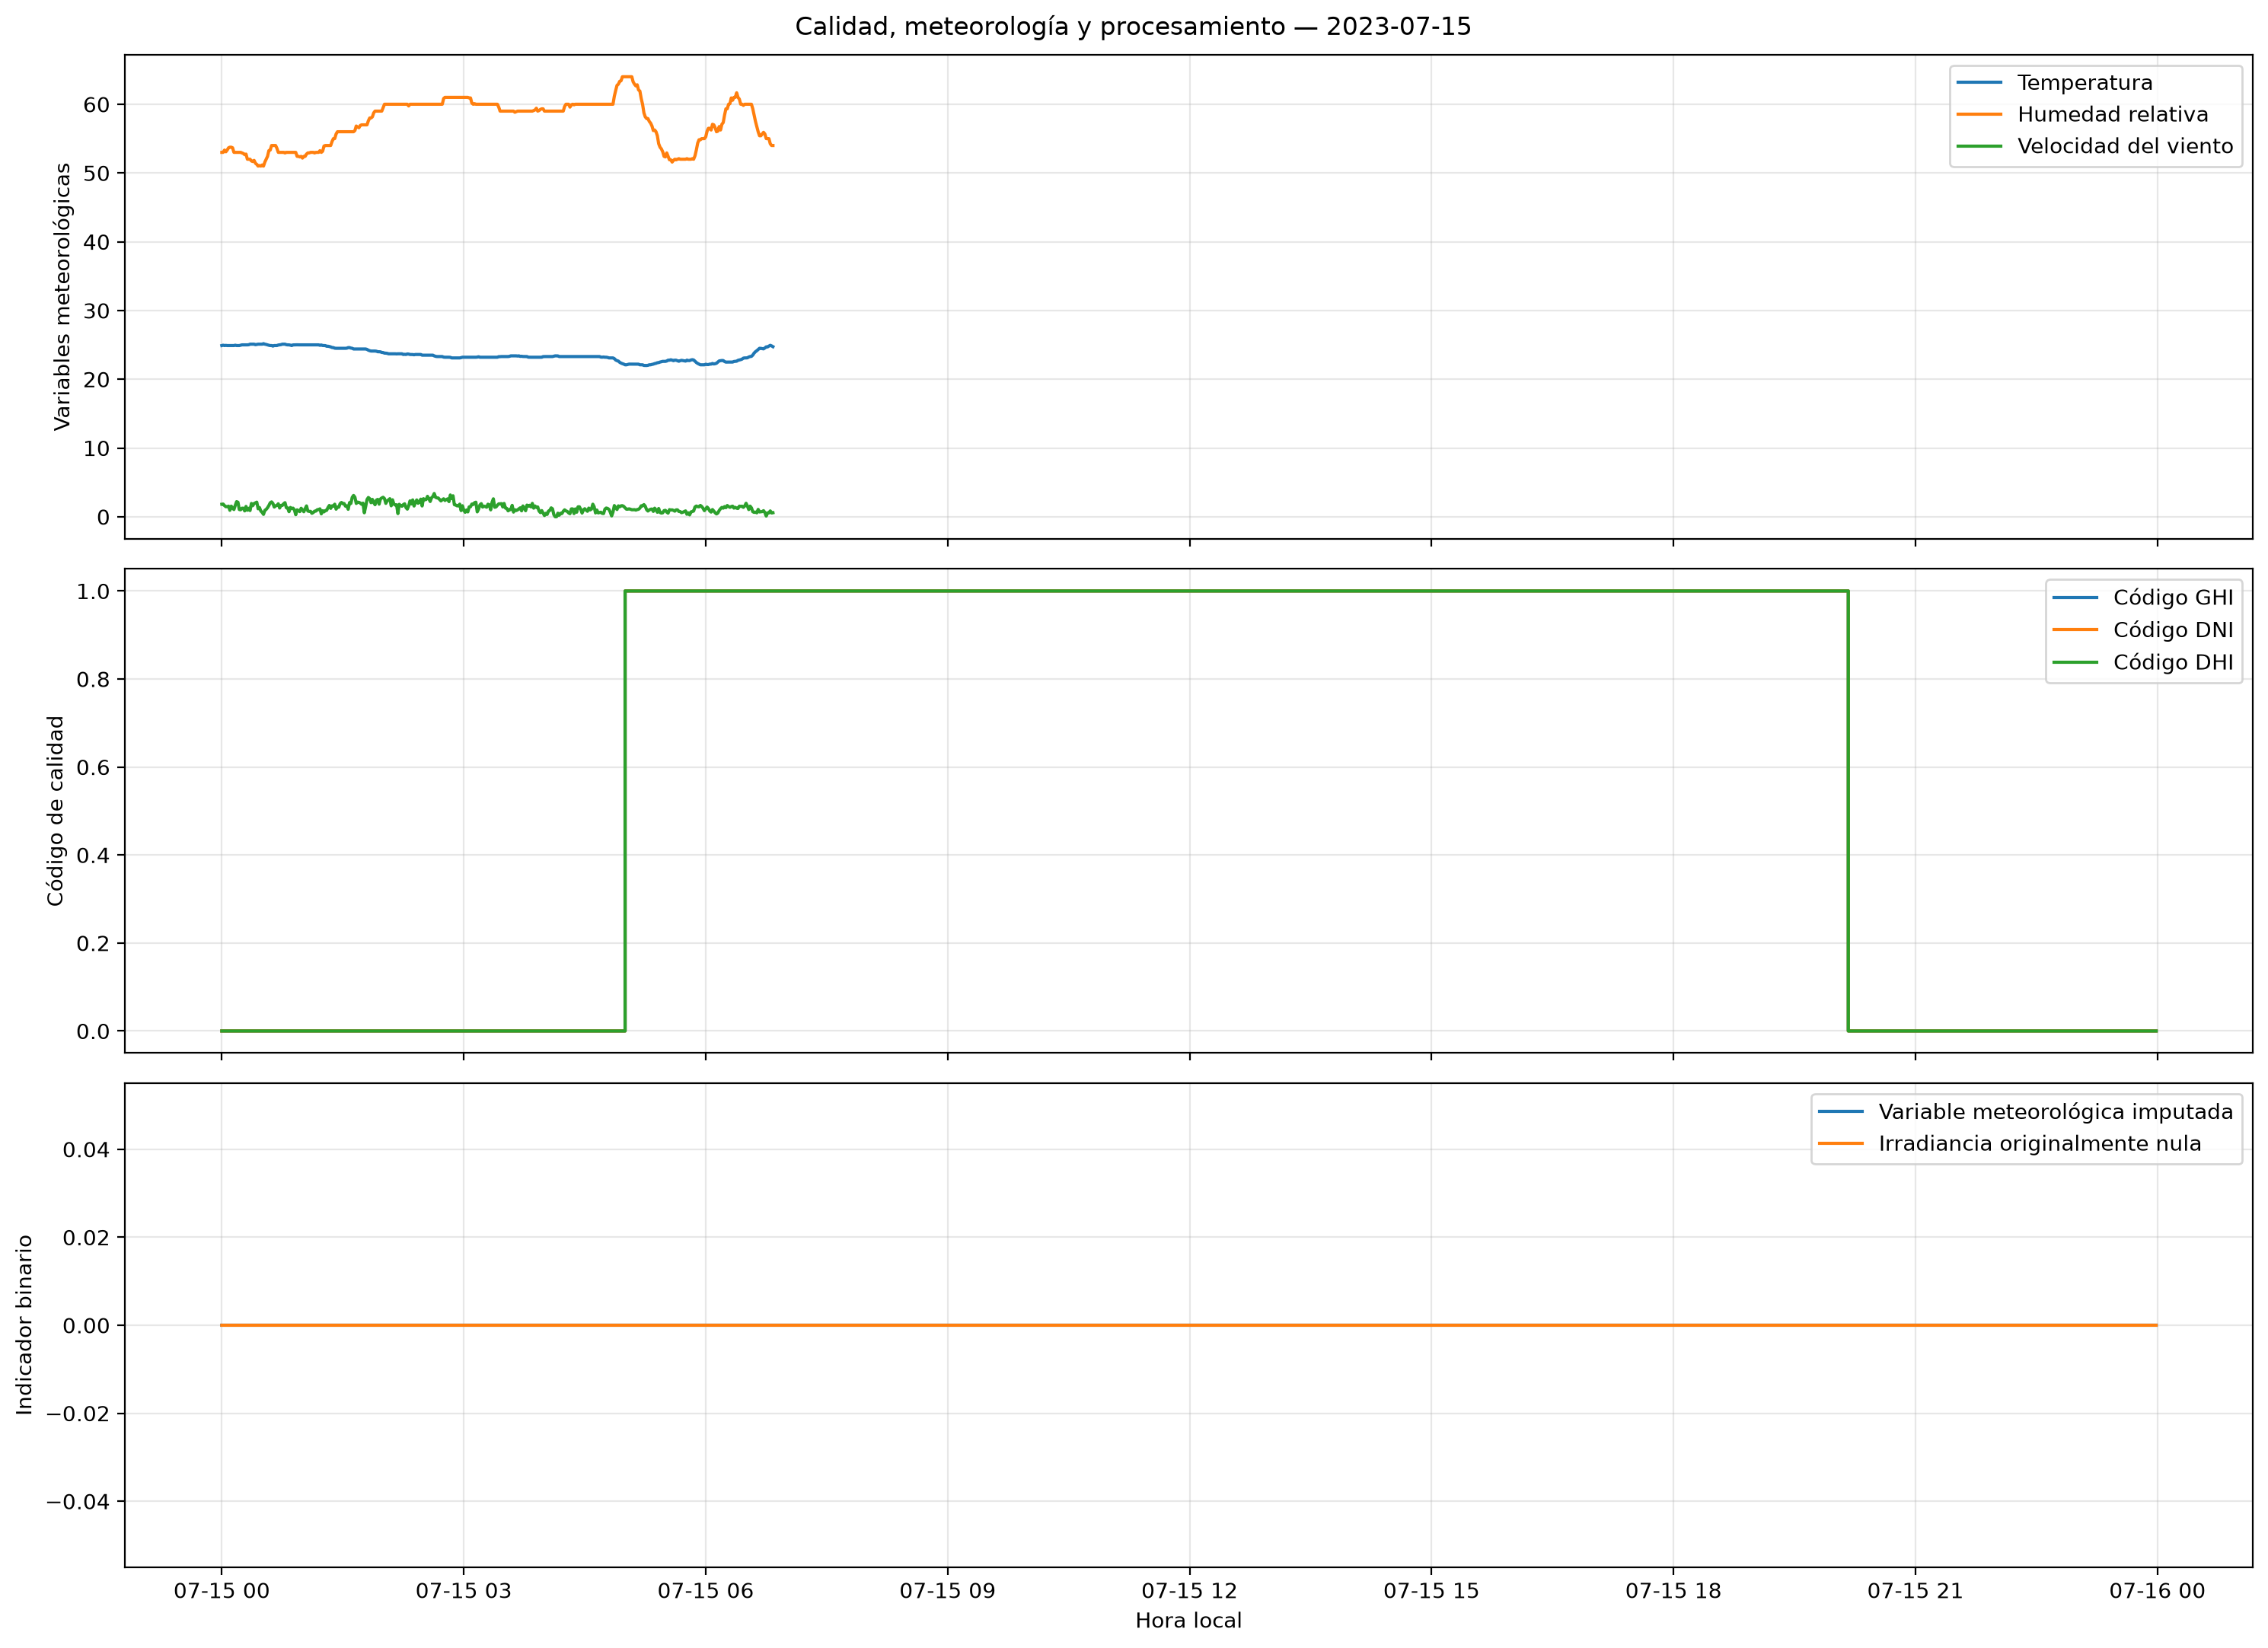

In [64]:
display(
    Image(
        filename=str(quality_weather_path)
    )
)

In [65]:
generation_time = datetime.now(timezone.utc)

daily_document["graficas"] = {
    "curvas_solares": {
        "disponible": True,
        "ruta": solar_curves_path.as_posix(),
        "formato": "png",
        "fecha_generacion": generation_time,
    },
    "calidad_meteorologia": {
        "disponible": True,
        "ruta": quality_weather_path.as_posix(),
        "formato": "png",
        "fecha_generacion": generation_time,
    },
}

daily_document["metadatos"]["updated_at"] = generation_time

In [66]:
from bson import BSON

try:
    encoded_document = BSON.encode(daily_document)

    print(
        "Documento compatible con BSON."
    )

    print(
        f"Tamaño del documento: "
        f"{len(encoded_document) / 1024:.2f} KB"
    )

except Exception as exc:
    raise TypeError(
        "El documento actualizado contiene tipos "
        "incompatibles con MongoDB."
    ) from exc

Documento compatible con BSON.
Tamaño del documento: 3.06 KB


In [67]:
from pprint import pprint

pprint(
    daily_document["graficas"],
    sort_dicts=False,
    width=120,
)

{'curvas_solares': {'disponible': True,
                    'ruta': '../outputs/daily_plots/2023/2023-07-15_solar_curves.png',
                    'formato': 'png',
                    'fecha_generacion': datetime.datetime(2026, 7, 28, 16, 53, 14, 191676, tzinfo=datetime.timezone.utc)},
 'calidad_meteorologia': {'disponible': True,
                          'ruta': '../outputs/daily_plots/2023/2023-07-15_quality_weather.png',
                          'formato': 'png',
                          'fecha_generacion': datetime.datetime(2026, 7, 28, 16, 53, 14, 191676, tzinfo=datetime.timezone.utc)}}


## Resultado

Se han generado y validado dos representaciones gráficas para una fecha de prueba:

- las curvas diarias de GHI, DNI, DHI y GHI estimado;
- la evolución de las variables meteorológicas, los códigos de calidad y los indicadores de procesamiento.

Las imágenes se almacenan como archivos PNG en el sistema de archivos del proyecto. El documento diario no contiene los archivos binarios, sino sus rutas, formato y fecha de generación.

El documento actualizado mantiene una estructura compatible con BSON y queda preparado para su posterior inserción en MongoDB.

En esta fase todavía no se han generado las gráficas para todas las fechas ni se ha realizado ninguna inserción en MongoDB Atlas.